In [ ]:
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT =  Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

json_file = RAW_DATA_DIR / "games.json"

with open(json_file, "r", encoding="utf-8") as f:
    games = json.load(f)

print(f"Loaded {len(games):,} games")

Loaded 135,140 games


In [ ]:
records = []

for appid, game in games.items():
    row = game.copy()
    row["appid"] = int(appid)
    records.append(row)

df = pd.DataFrame(records)

df.head()

,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,...,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,appid
0,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 0,0,0,0,0,0,0,[],2539430
1,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,8,0,8,0,65,0,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",496350
2,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,0,0,0,0,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...",1034400
3,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,1,[],3292190
4,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,0,[],3631080


In [ ]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year

df[["name", "release_date", "release_year"]].head()

,name,release_date,release_year
0,Black Dragon Mage Playtest,2023-08-01,2023
1,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016
2,Mystery Solitaire The Black Raven,2019-05-06,2019
3,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024
4,Maze Quest VR,2025-04-24,2025


In [ ]:
import pandas as pd

current_year = 2026

games_per_year = (
    df[
        (df["release_year"] >= 2010)
        & (df["release_year"] <= current_year)
    ]
    .groupby("release_year")
    .size()
    .reset_index(name="actual_games")
)

games_per_year

,release_year,actual_games
0,2010,255
1,2011,260
2,2012,322
3,2013,468
4,2014,1524
5,2015,2517
6,2016,4143
7,2017,5927
8,2018,7461
9,2019,7245


In [ ]:
# Use only completed years for the growth calculation
recent = games_per_year[
    games_per_year["release_year"].between(2022, 2025)
].copy()

# Calculate year-over-year percentage growth
recent["growth_rate"] = recent["actual_games"].pct_change()

# Average the completed annual growth rates
average_growth_rate = recent["growth_rate"].dropna().mean()

# Use 2025 as the base for the 2026 estimate
previous_year_total = int(
    games_per_year.loc[
        games_per_year["release_year"] == 2025,
        "actual_games"
    ].iloc[0]
)

projected_total = round(
    previous_year_total * (1 + average_growth_rate)
)

actual_current_year = int(
    games_per_year.loc[
        games_per_year["release_year"] == current_year,
        "actual_games"
    ].iloc[0]
)

projected_remaining = max(
    projected_total - actual_current_year,
    0
)

print(recent)
print()
print(f"Average annual growth: {average_growth_rate:.2%}")
print(f"{current_year} released so far: {actual_current_year:,}")
print(f"{current_year} estimated total: {projected_total:,}")
print(f"Estimated remaining releases: {projected_remaining:,}")

    release_year  actual_games  growth_rate
12          2022         12288          NaN
13          2023         14603     0.188395
14          2024         20042     0.372458
15          2025         24976     0.246183

Average annual growth: 26.90%
2026 released so far: 12,564
2026 estimated total: 31,695
Estimated remaining releases: 19,131


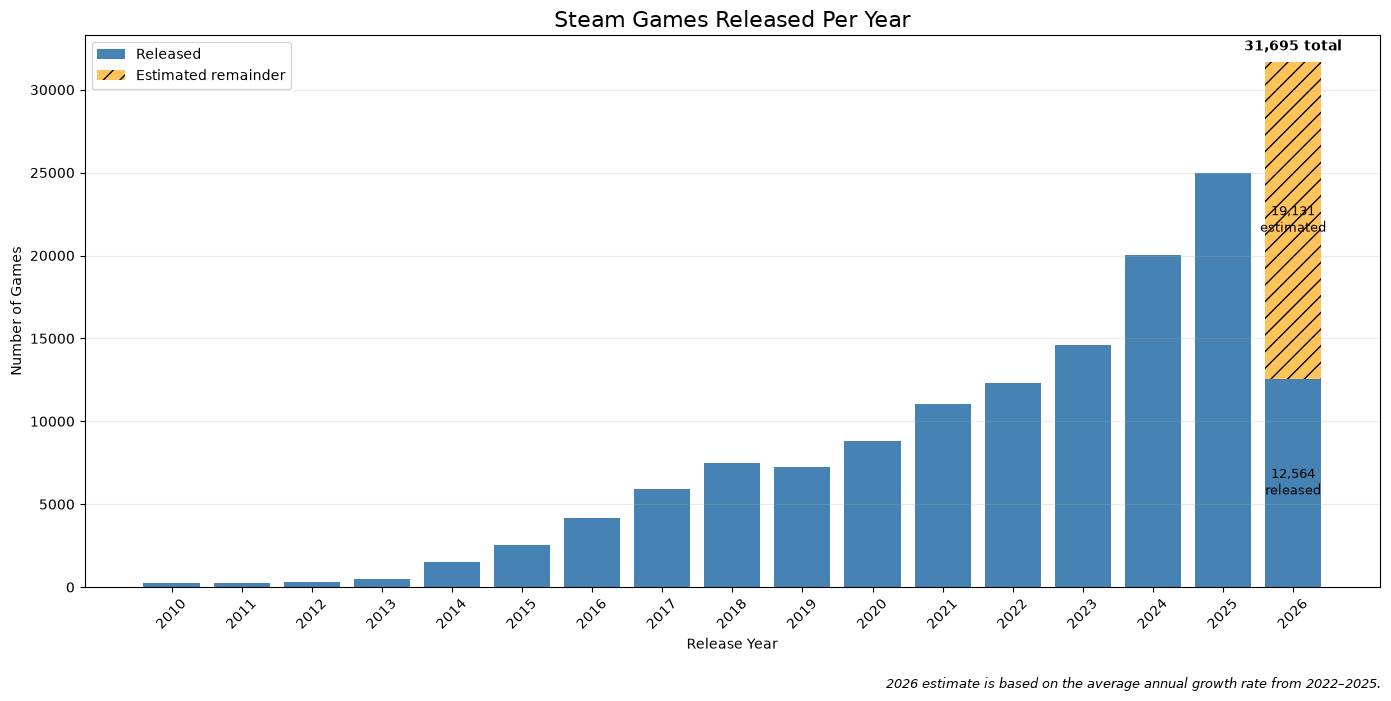

In [ ]:
import matplotlib.pyplot as plt

# Start with no projected portion for any year
games_per_year["projected_games"] = 0

# Add the estimated remainder only to 2026
games_per_year.loc[
    games_per_year["release_year"] == current_year,
    "projected_games"
] = projected_remaining

fig, ax = plt.subplots(figsize=(14, 7))

# Actual releases
ax.bar(
    games_per_year["release_year"],
    games_per_year["actual_games"],
    color="steelblue",
    label="Released"
)

# Estimated remainder stacked above actual 2026 releases
ax.bar(
    games_per_year["release_year"],
    games_per_year["projected_games"],
    bottom=games_per_year["actual_games"],
    color="orange",
    alpha=0.65,
    hatch="//",
    label="Estimated remainder"
)

ax.set_title(
    "Steam Games Released Per Year",
    fontsize=16
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Games")

ax.set_xticks(games_per_year["release_year"])
ax.tick_params(axis="x", rotation=45)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

# Label the actual and estimated parts of the 2026 bar
ax.text(
    current_year,
    actual_current_year / 2,
    f"{actual_current_year:,}\nreleased",
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    current_year,
    actual_current_year + projected_remaining / 2,
    f"{projected_remaining:,}\nestimated",
    ha="center",
    va="center",
    fontsize=9
)

# Show the estimated full-year total above the 2026 bar
ax.text(
    current_year,
    projected_total + projected_total * 0.015,
    f"{projected_total:,} total",
    ha="center",
    va="bottom",
    fontweight="bold"
)

fig.text(
    0.99,
    0.01,
    (
        "2026 estimate is based on the average annual "
        "growth rate from 2022–2025."
    ),
    ha="right",
    fontsize=9,
    style="italic"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [ ]:
yearly_table = (
    df.dropna(subset=["release_year"])
    .groupby("release_year")
    .size()
    .reset_index(name="Games")
    .sort_values("release_year")
)

# Calculate YoY growth before filtering out earlier years
yearly_table["YoY Growth"] = yearly_table["Games"].pct_change()

# Keep only 2010 onward for display
yearly_table = yearly_table[
    yearly_table["release_year"] >= 2010
].copy()

yearly_table = yearly_table.rename(
    columns={"release_year": "Year"}
)

yearly_table["Status"] = "Actual"

# Replace incomplete 2026 value with projected full-year total
yearly_table.loc[
    yearly_table["Year"] == current_year,
    "Games"
] = projected_total

yearly_table.loc[
    yearly_table["Year"] == current_year,
    "Status"
] = "Estimated"

# Recalculate 2026 growth using the projected total
previous_year_games = yearly_table.loc[
    yearly_table["Year"] == current_year - 1,
    "Games"
].iloc[0]

yearly_table.loc[
    yearly_table["Year"] == current_year,
    "YoY Growth"
] = projected_total / previous_year_games - 1

yearly_table = yearly_table[
    ["Year", "Games", "YoY Growth", "Status"]
]

yearly_table

,Year,Games,YoY Growth,Status
13,2010,255,-0.205607,Actual
14,2011,260,0.019608,Actual
15,2012,322,0.238462,Actual
16,2013,468,0.453416,Actual
17,2014,1524,2.256410,Actual
18,2015,2517,0.651575,Actual
19,2016,4143,0.646007,Actual
20,2017,5927,0.430606,Actual
21,2018,7461,0.258816,Actual
22,2019,7245,-0.028951,Actual


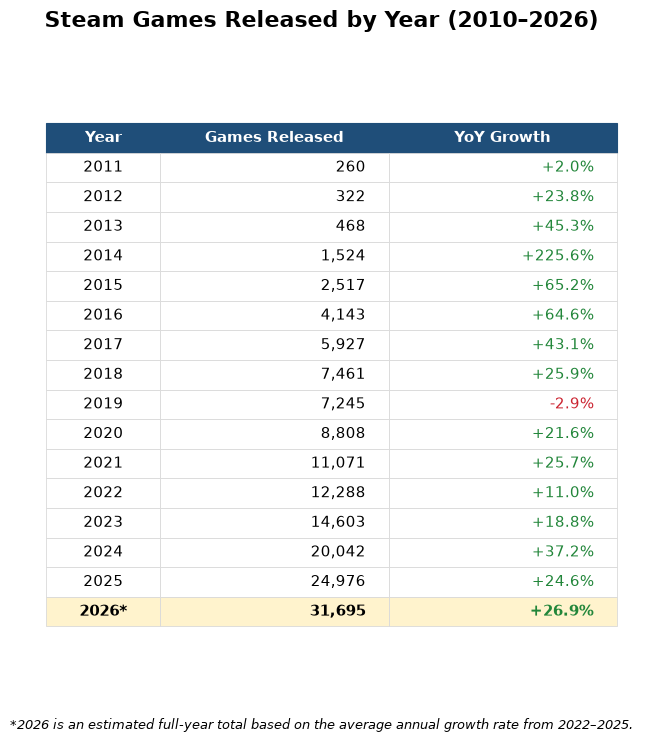

Saved to: d:\Workstation\python\steam-analysis\outputs\tables\steam_games_by_year.png


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ----------------------------
# Prepare display table
# ----------------------------

image_table = yearly_table[
    yearly_table["Year"] >= 2011
][["Year", "Games", "YoY Growth"]].copy()

# Preserve numeric growth values for coloring later
growth_values = image_table["YoY Growth"].copy()

# Convert Year to string before adding an asterisk
image_table["Year"] = (
    image_table["Year"]
    .astype(int)
    .astype(str)
)

image_table.loc[
    image_table["Year"] == str(current_year),
    "Year"
] = f"{current_year}*"

# Format values for display
image_table["Games"] = image_table["Games"].map(
    lambda value: f"{int(round(value)):,}"
)

image_table["YoY Growth"] = image_table["YoY Growth"].map(
    lambda value: "—" if pd.isna(value) else f"{value:+.1%}"
)

# ----------------------------
# Create figure
# ----------------------------

row_count = len(image_table)

fig, ax = plt.subplots(
    figsize=(8, row_count * 0.4 + 1.2)
)

ax.axis("off")

table = ax.table(
    cellText=image_table.values,
    colLabels=[
        "Year",
        "Games Released",
        "YoY Growth"
    ],
    cellLoc="center",
    colLoc="center",
    bbox=[0.04, 0.07, 0.92, 0.86],
    colWidths=[0.20, 0.40, 0.40]
)

table.auto_set_font_size(False)
table.set_fontsize(11)

# ----------------------------
# Style cells
# ----------------------------

for (row, column), cell in table.get_celld().items():

    if row == 0:
        cell.set_facecolor("#1f4e79")
        cell.set_text_props(
            color="white",
            weight="bold"
        )
        cell.set_edgecolor("#1f4e79")
        cell.set_linewidth(0.8)

    else:
        cell.set_facecolor("white")
        cell.set_edgecolor("#d9d9d9")
        cell.set_linewidth(0.6)

        displayed_year = image_table.iloc[row - 1]["Year"]

        # Highlight projected year
        if displayed_year == f"{current_year}*":
            cell.set_facecolor("#fff3cd")
            cell.set_text_props(weight="bold")

# Right-align numeric columns
for row in range(1, row_count + 1):
    table[(row, 1)].get_text().set_ha("right")
    table[(row, 2)].get_text().set_ha("right")

# Color growth values
for row, growth in enumerate(growth_values, start=1):

    if pd.isna(growth):
        continue

    if growth > 0:
        table[(row, 2)].get_text().set_color("#22863a")

    elif growth < 0:
        table[(row, 2)].get_text().set_color("#cb2431")

# ----------------------------
# Title and footnote
# ----------------------------

fig.suptitle(
    f"Steam Games Released by Year (2010–{current_year})",
    fontsize=16,
    fontweight="bold",
    y=0.975
)

fig.text(
    0.5,
    0.025,
    (
        f"*{current_year} is an estimated full-year total based on "
        "the average annual growth rate from 2022–2025."
    ),
    ha="center",
    va="bottom",
    fontsize=9,
    style="italic"
)

# ----------------------------
# Save image
# ----------------------------

output_dir = PROJECT_ROOT / "outputs" / "tables"
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = output_dir / "steam_games_by_year.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(f"Saved to: {output_path}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Estimated number of owners/sales per Steam review
REVIEW_MULTIPLIER = 45

# Years to include
START_YEAR = 2010
END_YEAR = 2025

# Number of tags retained per year
TOP_N = 10

In [ ]:
games_revenue = df.copy()

# Ensure required numeric columns are numeric
numeric_columns = [
    "positive",
    "negative",
    "price",
    "release_year"
]

for column in numeric_columns:
    games_revenue[column] = pd.to_numeric(
        games_revenue[column],
        errors="coerce"
    )

# Keep only the desired years
games_revenue = games_revenue[
    games_revenue["release_year"].between(
        START_YEAR,
        END_YEAR
    )
].copy()

# Replace missing review counts with zero
games_revenue["positive"] = (
    games_revenue["positive"]
    .fillna(0)
    .clip(lower=0)
)

games_revenue["negative"] = (
    games_revenue["negative"]
    .fillna(0)
    .clip(lower=0)
)

# Replace missing or negative prices with zero
games_revenue["price"] = (
    games_revenue["price"]
    .fillna(0)
    .clip(lower=0)
)

# Total Steam reviews
games_revenue["total_reviews"] = (
    games_revenue["positive"]
    + games_revenue["negative"]
)

# Estimate copies sold
games_revenue["estimated_copies"] = (
    games_revenue["total_reviews"]
    * REVIEW_MULTIPLIER
)

# Estimate gross revenue
games_revenue["estimated_revenue"] = (
    games_revenue["estimated_copies"]
    * games_revenue["price"]
)

games_revenue[
    [
        "release_year",
        "positive",
        "negative",
        "total_reviews",
        "price",
        "estimated_copies",
        "estimated_revenue"
    ]
].head()

,release_year,positive,negative,total_reviews,price,estimated_copies,estimated_revenue
0,2023,0,0,0,0.00,0,0.0
1,2016,252,3,255,5.24,11475,60129.0
2,2019,21,3,24,4.99,1080,5389.2
3,2024,0,0,0,8.99,0,0.0
4,2025,0,0,0,4.99,0,0.0


In [ ]:
def clean_tags(tags):
    """
    Return a list of valid tag names from a Steam tags dictionary.
    """

    if not isinstance(tags, dict):
        return []

    valid_tags = []

    for tag, weight in tags.items():

        if not isinstance(tag, str):
            continue

        tag = tag.strip()

        if not tag:
            continue

        # Keep only tags with a positive Steam tag score
        try:
            weight = float(weight)
        except (TypeError, ValueError):
            continue

        if weight <= 0:
            continue

        valid_tags.append(tag)

    # Remove any accidental duplicates while preserving order
    return list(dict.fromkeys(valid_tags))


games_revenue["tag_list"] = games_revenue["tags"].apply(
    clean_tags
)

games_revenue["tag_count"] = games_revenue["tag_list"].str.len()

# Keep only games that have at least one valid tag
games_with_tags = games_revenue[
    games_revenue["tag_count"] > 0
].copy()

games_with_tags[
    [
        "release_year",
        "estimated_revenue",
        "tag_list",
        "tag_count"
    ]
].head()

,release_year,estimated_revenue,tag_list,tag_count
6,2025,210541.5,"[Simulation, Strategy, RTS, Wargame, Grand Str...",18
13,2023,4425.3,"[Casual, Strategy, Puzzle, City Builder, Table...",17
14,2024,2673.0,"[Dog, Cute, Walking Simulator, Psychological H...",20
16,2023,126.0,"[Action, Shooter, Puzzle, Puzzle-Platformer, C...",10
28,2024,1617.3,"[Adventure, Sports, Arcade, Runner, 3D, Action...",16


In [ ]:
# Equal revenue allocation per tag
games_with_tags["revenue_per_tag"] = (
    games_with_tags["estimated_revenue"]
    / games_with_tags["tag_count"]
)

# Convert each game's list of tags into separate rows
tag_revenue_rows = (
    games_with_tags[
        [
            "release_year",
            "tag_list",
            "estimated_revenue",
            "revenue_per_tag"
        ]
    ]
    .explode("tag_list")
    .rename(columns={"tag_list": "tag"})
)

tag_revenue_rows.head()

,release_year,tag,estimated_revenue,revenue_per_tag
6,2025,Simulation,210541.5,11696.75
6,2025,Strategy,210541.5,11696.75
6,2025,RTS,210541.5,11696.75
6,2025,Wargame,210541.5,11696.75
6,2025,Grand Strategy,210541.5,11696.75


In [ ]:
original_revenue = games_with_tags[
    "estimated_revenue"
].sum()

allocated_revenue = tag_revenue_rows[
    "revenue_per_tag"
].sum()

print(
    f"Original estimated revenue:  ${original_revenue:,.2f}"
)

print(
    f"Allocated tag revenue:       ${allocated_revenue:,.2f}"
)

print(
    f"Difference:                  "
    f"${allocated_revenue - original_revenue:,.6f}"
)

assert np.isclose(
    original_revenue,
    allocated_revenue
), "Allocated tag revenue does not match original revenue."

Original estimated revenue:  $24,468,527,213.10
Allocated tag revenue:       $24,468,527,213.10
Difference:                  $-0.000004


In [ ]:
tag_revenue_by_year = (
    tag_revenue_rows
    .groupby(
        ["release_year", "tag"],
        as_index=False
    )
    .agg(
        estimated_revenue=(
            "revenue_per_tag",
            "sum"
        ),
        game_count=(
            "tag",
            "size"
        )
    )
)

tag_revenue_by_year = tag_revenue_by_year.sort_values(
    ["release_year", "estimated_revenue"],
    ascending=[True, False]
)

tag_revenue_by_year.head(20)

,release_year,tag,estimated_revenue,game_count
344,2022,Singleplayer,2.408036e+08,6704
17,2022,Action,2.198635e+08,3734
270,2022,Open World,1.800412e+08,692
247,2022,Multiplayer,1.795474e+08,1031
385,2022,Third Person,1.631954e+08,993
304,2022,RPG,1.602440e+08,1689
38,2022,Atmospheric,1.511343e+08,2048
7,2022,3D,1.399205e+08,2834
80,2022,Co-op,1.387197e+08,478
173,2022,Great Soundtrack,1.288990e+08,89


In [ ]:
top_tags_by_year = (
    tag_revenue_by_year
    .sort_values(
        ["release_year", "estimated_revenue"],
        ascending=[True, False]
    )
    .groupby(
        "release_year",
        group_keys=False
    )
    .head(TOP_N)
    .copy()
)

# Rank tags within each year
top_tags_by_year["rank"] = (
    top_tags_by_year
    .groupby("release_year")["estimated_revenue"]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

top_tags_by_year[
    [
        "release_year",
        "rank",
        "tag",
        "estimated_revenue",
        "game_count"
    ]
].sort_values(
    ["release_year", "rank"]
)

,release_year,rank,tag,estimated_revenue,game_count
344,2022,1,Singleplayer,2.408036e+08,6704
17,2022,2,Action,2.198635e+08,3734
270,2022,3,Open World,1.800412e+08,692
247,2022,4,Multiplayer,1.795474e+08,1031
385,2022,5,Third Person,1.631954e+08,993
304,2022,6,RPG,1.602440e+08,1689
38,2022,7,Atmospheric,1.511343e+08,2048
7,2022,8,3D,1.399205e+08,2834
80,2022,9,Co-op,1.387197e+08,478
173,2022,10,Great Soundtrack,1.288990e+08,89


In [ ]:
top_tags_by_year["top_10_revenue"] = (
    top_tags_by_year
    .groupby("release_year")[
        "estimated_revenue"
    ]
    .transform("sum")
)

top_tags_by_year["share"] = (
    top_tags_by_year["estimated_revenue"]
    / top_tags_by_year["top_10_revenue"]
)

top_tags_by_year["share_percent"] = (
    top_tags_by_year["share"] * 100
)

top_tags_by_year[
    [
        "release_year",
        "rank",
        "tag",
        "estimated_revenue",
        "share_percent"
    ]
].sort_values(
    ["release_year", "rank"]
)

,release_year,rank,tag,estimated_revenue,share_percent
344,2022,1,Singleplayer,2.408036e+08,14.145212
17,2022,2,Action,2.198635e+08,12.915151
270,2022,3,Open World,1.800412e+08,10.575924
247,2022,4,Multiplayer,1.795474e+08,10.546915
385,2022,5,Third Person,1.631954e+08,9.586373
304,2022,6,RPG,1.602440e+08,9.413004
38,2022,7,Atmospheric,1.511343e+08,8.877885
7,2022,8,3D,1.399205e+08,8.219163
80,2022,9,Co-op,1.387197e+08,8.148629
173,2022,10,Great Soundtrack,1.288990e+08,7.571743


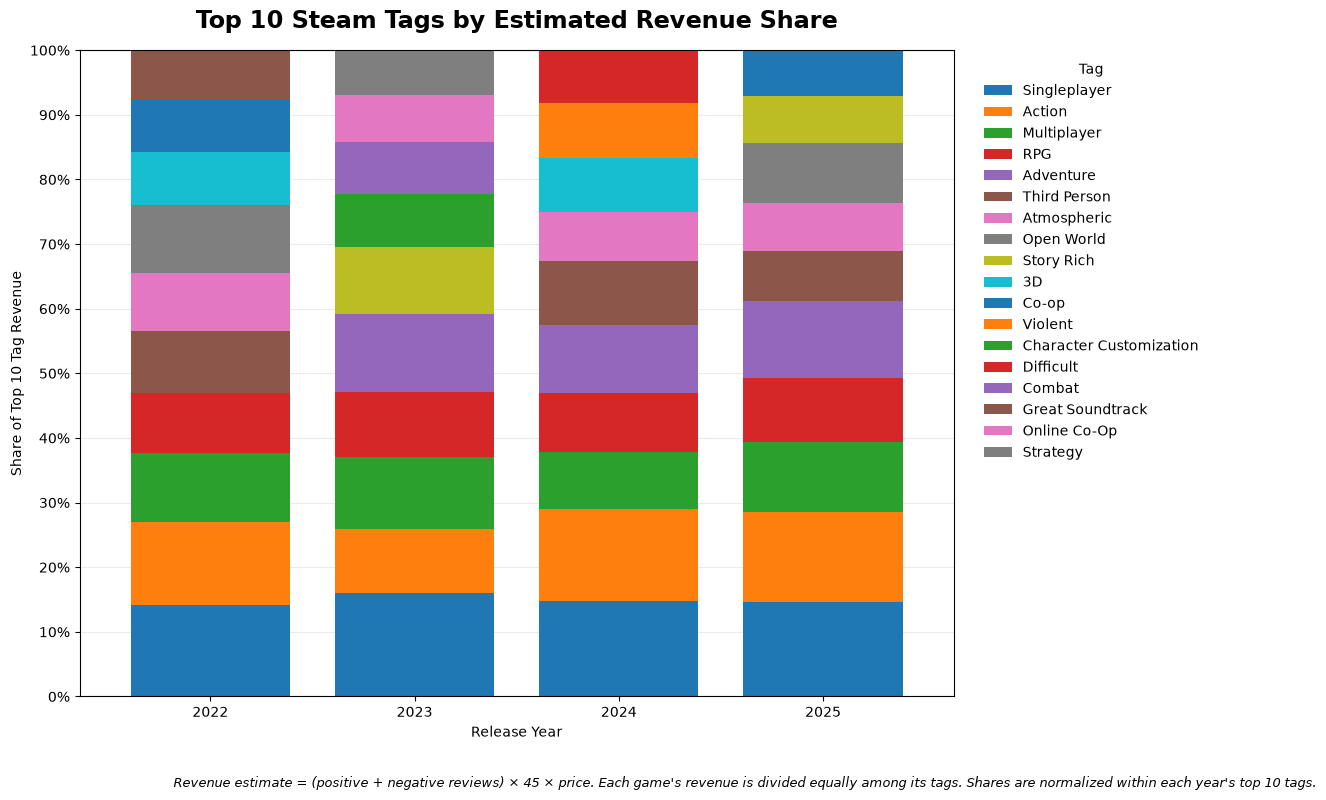

In [ ]:
tag_share_pivot = (
    top_tags_by_year
    .pivot(
        index="release_year",
        columns="tag",
        values="share_percent"
    )
    .fillna(0)
    .sort_index()
)

# Order columns by total share across all displayed years
tag_order = (
    tag_share_pivot
    .sum(axis=0)
    .sort_values(ascending=False)
    .index
)

tag_share_pivot = tag_share_pivot[tag_order]

ax = tag_share_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 8),
    width=0.78
)

ax.set_title(
    "Top 10 Steam Tags by Estimated Revenue Share",
    fontsize=17,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Share of Top 10 Tag Revenue")

ax.set_ylim(0, 100)

ax.set_yticks(
    range(0, 101, 10)
)

ax.set_yticklabels(
    [f"{value}%" for value in range(0, 101, 10)]
)

ax.legend(
    title="Tag",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.xticks(rotation=0)

plt.figtext(
    0.5,
    0.01,
    (
        f"Revenue estimate = (positive + negative reviews) × "
        f"{REVIEW_MULTIPLIER} × price. "
        "Each game's revenue is divided equally among its tags. "
        "Shares are normalized within each year's top 10 tags."
    ),
    ha="center",
    fontsize=9,
    style="italic",
    wrap=True
)

plt.tight_layout(
    rect=[0, 0.05, 0.82, 1]
)

plt.show()

In [ ]:
yearly_revenue = (
    games_revenue
    .groupby("release_year", as_index=False)
    .agg(
        estimated_revenue=("estimated_revenue", "sum")
    )
    .sort_values("release_year")
)

yearly_revenue

,release_year,estimated_revenue
0,2022,5.237302e+09
1,2023,5.760460e+09
2,2024,1.056352e+10
3,2025,2.907246e+09


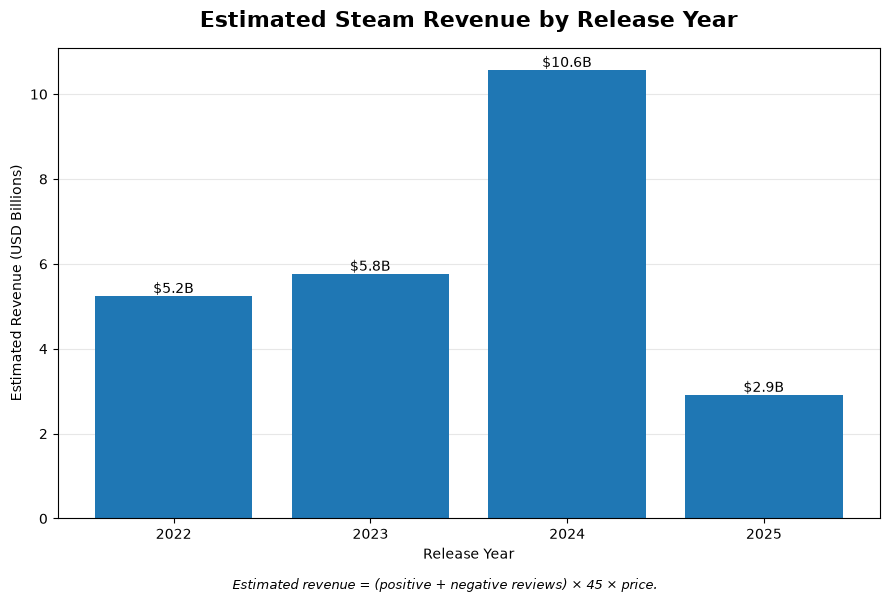

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    yearly_revenue["release_year"].astype(str),
    yearly_revenue["estimated_revenue"] / 1e9
)

ax.set_title(
    "Estimated Steam Revenue by Release Year",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Estimated Revenue (USD Billions)")

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)

# Labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:.1f}B",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.figtext(
    0.5,
    0.01,
    (
        f"Estimated revenue = (positive + negative reviews) × "
        f"{REVIEW_MULTIPLIER} × price."
    ),
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()

In [ ]:
summary = (
    games_revenue
    .groupby("release_year")
    .agg(
        games=("appid", "count"),
        reviews=("total_reviews", "sum"),
        avg_reviews=("total_reviews", "mean"),
        median_reviews=("total_reviews", "median"),
        avg_price=("price", "mean"),
        revenue=("estimated_revenue", "sum")
    )
)

summary

,games,reviews,avg_reviews,median_reviews,avg_price,revenue
release_year,,,,,,
2022,12288,8570998,697.509603,6.0,4.718332,5.237302e+09
2023,14603,8161692,558.905156,4.0,4.999075,5.760460e+09
2024,20042,10061494,502.020457,3.0,5.070325,1.056352e+10
2025,24976,3284048,131.488149,0.0,5.078750,2.907246e+09


In [ ]:
zero_review_games = (
    games_revenue
    .assign(
        total_reviews=lambda d: d["positive"] + d["negative"]
    )
    .groupby("release_year")
    .agg(
        total_games=("appid", "count"),
        zero_review_games=("total_reviews", lambda x: (x < 20).sum())
    )
)

zero_review_games["percent_zero"] = (
    zero_review_games["zero_review_games"]
    / zero_review_games["total_games"]
    * 100
)

zero_review_games

,total_games,zero_review_games,percent_zero
release_year,,,
2022,12288,8336,67.838542
2023,14603,10356,70.916935
2024,20042,15057,75.127233
2025,24976,22627,90.594971


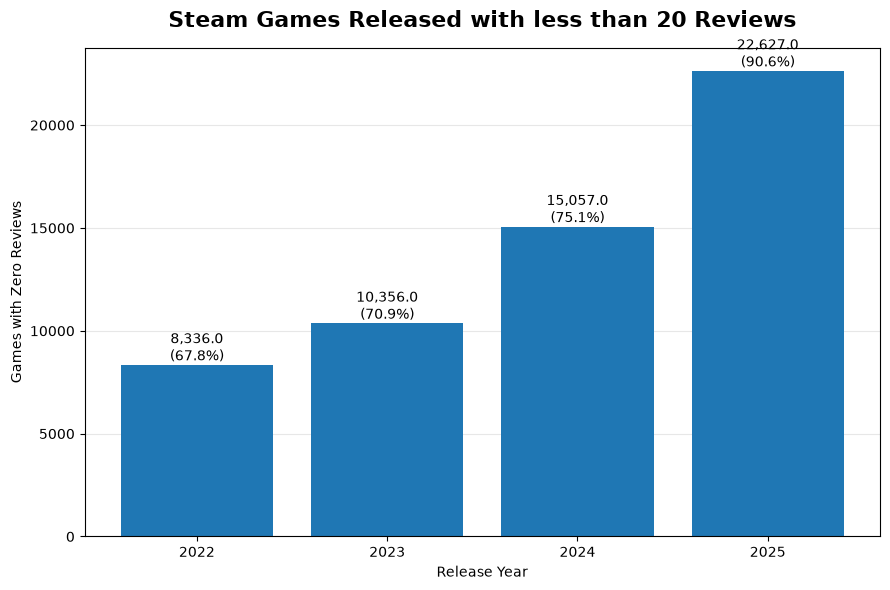

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))

bars = ax.bar(
    zero_review_games.index.astype(str),
    zero_review_games["zero_review_games"]
)

ax.set_title(
    "Steam Games Released with less than 20 Reviews",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Games with Zero Reviews")

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

for i, bar in enumerate(bars):

    count = zero_review_games.iloc[i]["zero_review_games"]
    pct = zero_review_games.iloc[i]["percent_zero"]

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
games_revenue.loc[
    games_revenue["total_reviews"] == 0,
    [
        "appid",
        "name",
        "release_year",
        "positive",
        "negative",
        "price"
    ]
].head(20)

,appid,name,release_year,positive,negative,price
0,2539430,Black Dragon Mage Playtest,2023,0,0,0.00
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024,0,0,8.99
4,3631080,Maze Quest VR,2025,0,0,4.99
5,1654170,Agony VR,2023,0,0,13.99
10,1946890,Codename: Warlock Playtest,2022,0,0,0.00
18,2260230,Midnight Dash,2023,0,0,0.00
19,2403000,Fantasy Amusement Park,2023,0,0,5.99
20,2713630,Black Market,2025,0,0,0.00
23,2072070,RPG Plus - Virtual Tabletop,2024,0,0,0.00
24,2349750,CyberVault Playtest,2023,0,0,0.00


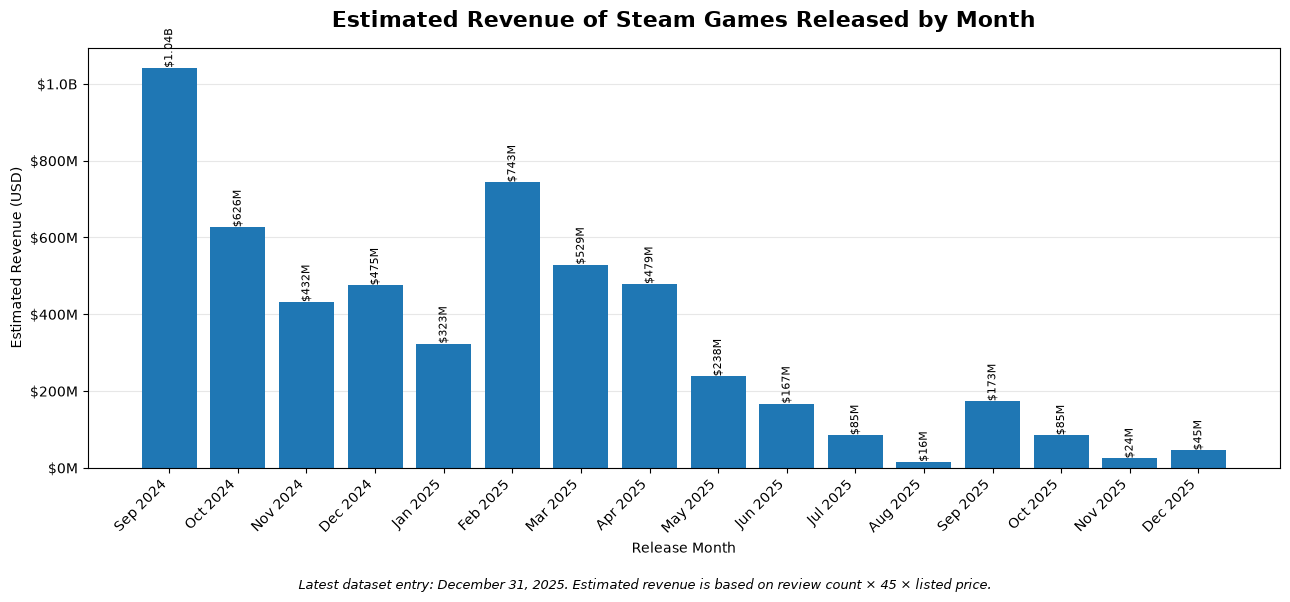

,release_month,estimated_revenue,month_label
0,2024-09,1.041652e+09,Sep 2024
1,2024-10,6.264740e+08,Oct 2024
2,2024-11,4.316356e+08,Nov 2024
3,2024-12,4.750516e+08,Dec 2024
4,2025-01,3.233275e+08,Jan 2025
5,2025-02,7.431769e+08,Feb 2025
6,2025-03,5.289894e+08,Mar 2025
7,2025-04,4.787040e+08,Apr 2025
8,2025-05,2.380892e+08,May 2025
9,2025-06,1.670392e+08,Jun 2025


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Use your existing dataframe
monthly_df = games_revenue.copy()

# Ensure release_date is a valid datetime column
monthly_df["release_date"] = pd.to_datetime(
    monthly_df["release_date"],
    errors="coerce"
)

# Recalculate estimated revenue only if it is not already present
if "estimated_revenue" not in monthly_df.columns:
    REVIEW_MULTIPLIER = 45

    monthly_df["total_reviews"] = (
        monthly_df["positive"].fillna(0)
        + monthly_df["negative"].fillna(0)
    )

    monthly_df["estimated_revenue"] = (
        monthly_df["total_reviews"]
        * REVIEW_MULTIPLIER
        * monthly_df["price"].fillna(0)
    )

# Remove rows without a usable release date
monthly_df = monthly_df.dropna(
    subset=["release_date"]
).copy()

# Find the latest release month represented in the dataset
latest_date = monthly_df["release_date"].max()
latest_month = latest_date.to_period("M")

# Include the latest month and the preceding 15 months
first_month = latest_month - 15
# Create the complete 16-month range
month_range = pd.period_range(
    start=first_month,
    end=latest_month,
    freq="M",
    name="release_month"
)

# Assign each game to a release month
monthly_df["release_month"] = (
    monthly_df["release_date"].dt.to_period("M")
)

# Aggregate revenue and include months with no releases
monthly_revenue = (
    monthly_df[
        monthly_df["release_month"].between(
            first_month,
            latest_month
        )
    ]
    .groupby("release_month")["estimated_revenue"]
    .sum()
    .reindex(month_range, fill_value=0)
    .rename("estimated_revenue")
    .rename_axis("release_month")
    .reset_index()
)

# Create readable month labels
monthly_revenue["month_label"] = (
    monthly_revenue["release_month"]
    .dt.to_timestamp()
    .dt.strftime("%b %Y")
)

# Plot
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(
    monthly_revenue["month_label"],
    monthly_revenue["estimated_revenue"]
)

ax.set_title(
    "Estimated Revenue of Steam Games Released by Month",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Month")
ax.set_ylabel("Estimated Revenue (USD)")

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: (
            f"${value / 1e9:.1f}B"
            if value >= 1e9
            else f"${value / 1e6:.0f}M"
        )
    )
)

ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.xticks(
    rotation=45,
    ha="right"
)

# Add values above bars
for bar in bars:
    value = bar.get_height()

    if value >= 1e9:
        label = f"${value / 1e9:.2f}B"
    else:
        label = f"${value / 1e6:.0f}M"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.figtext(
    0.5,
    0.01,
    (
        f"Latest dataset entry: {latest_date:%B %d, %Y}. "
        "Estimated revenue is based on review count × "
        f"{REVIEW_MULTIPLIER} × listed price."
    ),
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

monthly_revenue

Games included: 34,712


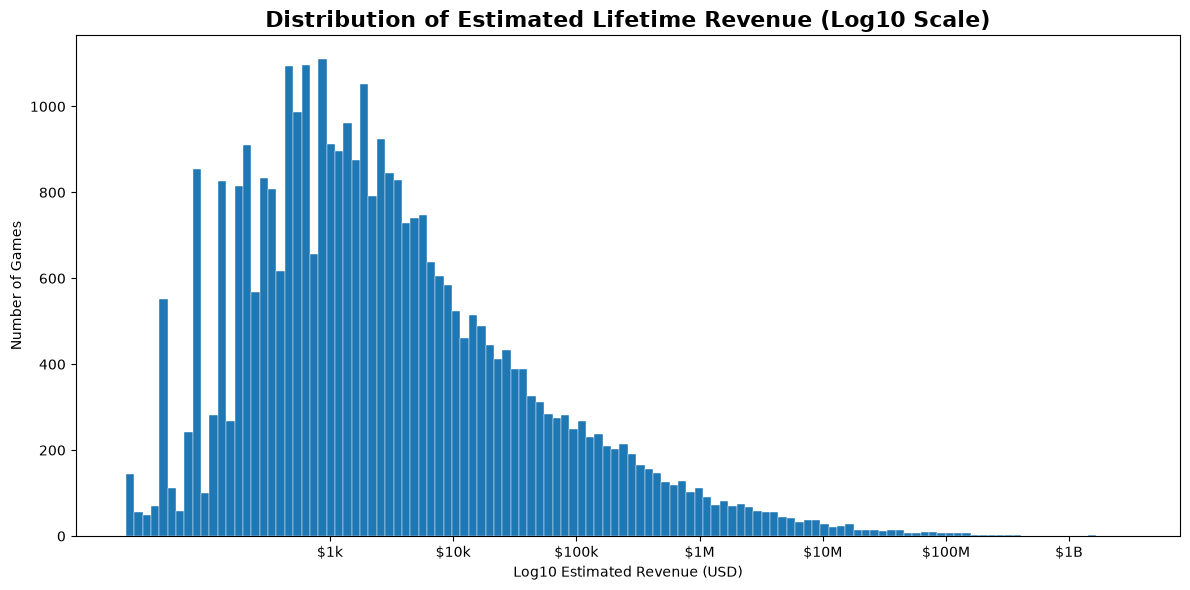

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Only games with positive estimated revenue
cluster_df = games_revenue[
    games_revenue["estimated_revenue"] > 0
].copy()

# Log10 revenue
cluster_df["log10_revenue"] = np.log10(cluster_df["estimated_revenue"])
# cluster_df["log10_revenue"] = cluster_df["estimated_revenue"]

print(f"Games included: {len(cluster_df):,}")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    cluster_df["log10_revenue"],
    bins=120,
    edgecolor="white",
    linewidth=0.3
)

ax.set_title(
    "Distribution of Estimated Lifetime Revenue (Log10 Scale)",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Log10 Estimated Revenue (USD)")
ax.set_ylabel("Number of Games")

# Useful reference labels
ticks = [3, 4, 5, 6, 7, 8, 9]
labels = [
    "$1k",
    "$10k",
    "$100k",
    "$1M",
    "$10M",
    "$100M",
    "$1B",
]

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

plt.tight_layout()
plt.show()

In [ ]:
cluster_df["log10_revenue"].describe(percentiles=np.linspace(0.1, 0.9, 9))

count    34712.000000
mean         3.472922
std          1.137487
min          1.343409
10%          2.196038
20%          2.526533
30%          2.794976
40%          3.032518
50%          3.275841
60%          3.555433
70%          3.882792
80%          4.347012
90%          5.065394
max          9.492026
Name: log10_revenue, dtype: float64

In [ ]:
import numpy as np
import pandas as pd

# Only released games with revenue
density_df = games_revenue[
    (games_revenue["estimated_revenue"] > 0)
    & (games_revenue["release_year"] >= 2010)
    & (games_revenue["release_year"] <= 2026)
].copy()

density_df["log10_revenue"] = np.log10(
    density_df["estimated_revenue"]
)

print(f"Games included: {len(density_df):,}")

Games included: 34,712


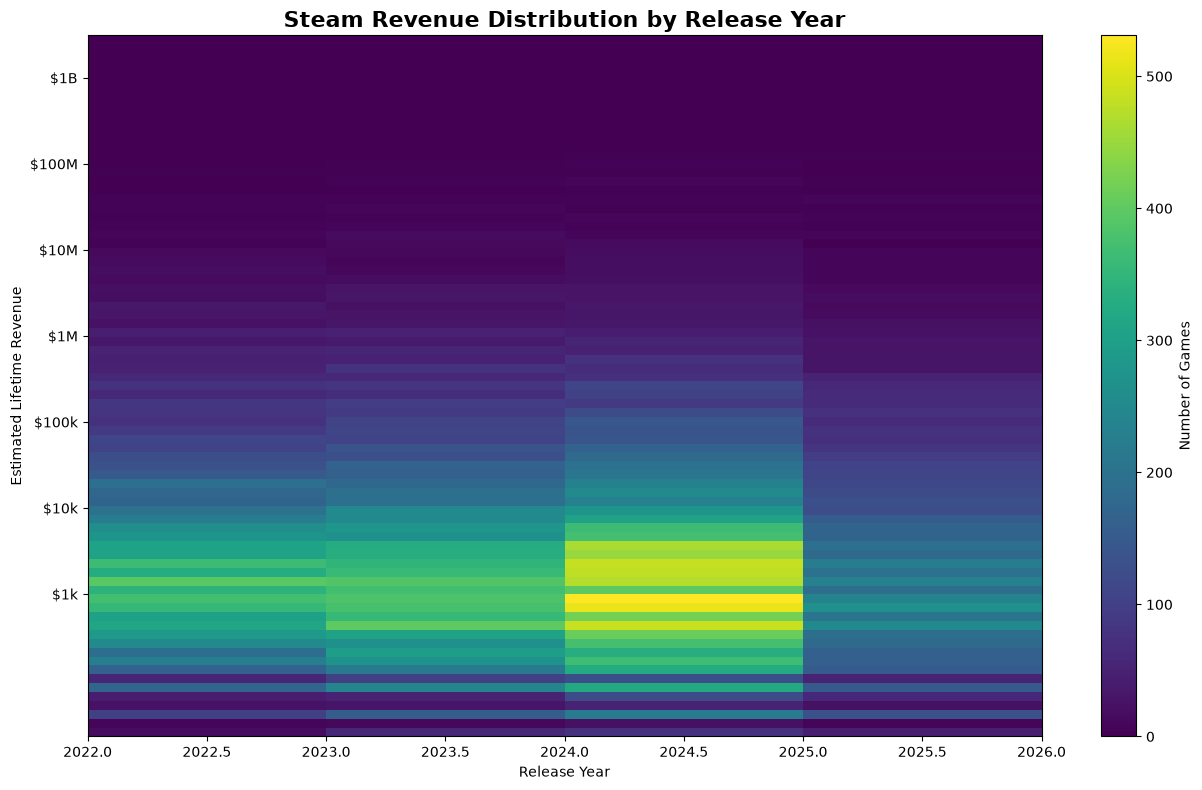

In [ ]:
import matplotlib.pyplot as plt

# Create 2D histogram
heatmap, xedges, yedges = np.histogram2d(
    density_df["release_year"],
    density_df["log10_revenue"],
    bins=[
        np.arange(2022, 2027),
        np.linspace(
            density_df["log10_revenue"].min(),
            density_df["log10_revenue"].max(),
            80
        )
    ]
)

fig, ax = plt.subplots(figsize=(13, 8))

im = ax.imshow(
    heatmap.T,
    origin="lower",
    aspect="auto",
    extent=[
        xedges[0],
        xedges[-1],
        yedges[0],
        yedges[-1]
    ]
)

cbar = plt.colorbar(im)
cbar.set_label("Number of Games")

ax.set_title(
    "Steam Revenue Distribution by Release Year",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Estimated Lifetime Revenue")

ticks = [3,4,5,6,7,8,9]
labels = [
    "$1k",
    "$10k",
    "$100k",
    "$1M",
    "$10M",
    "$100M",
    "$1B"
]

ax.set_yticks(ticks)
ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

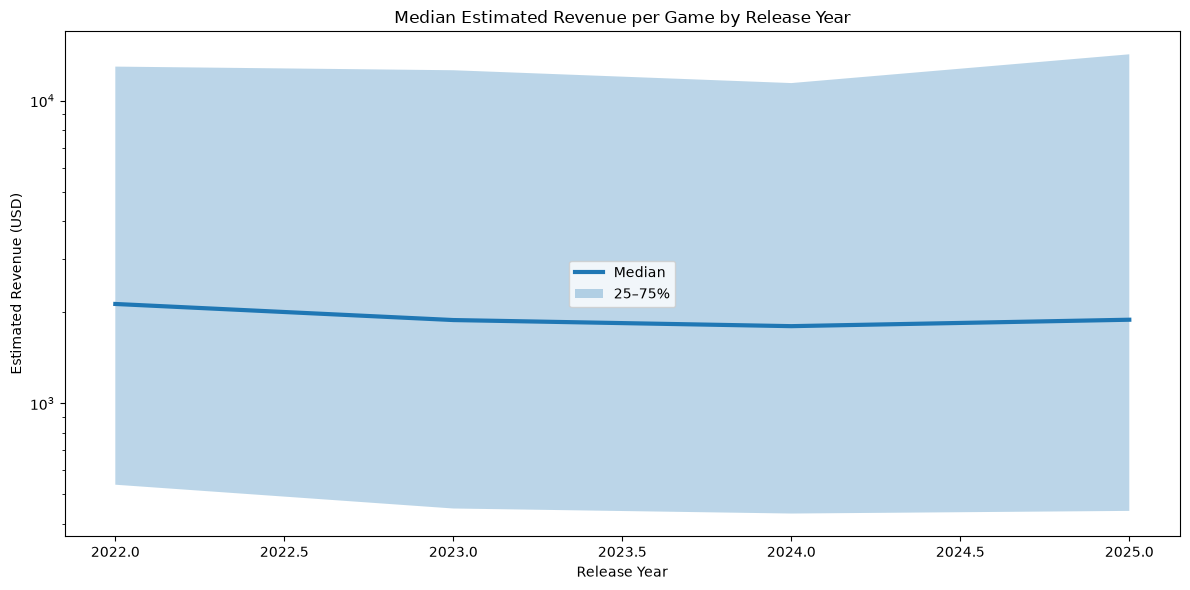

In [ ]:
summary = (
    density_df
    .groupby("release_year")
    .agg(
        q25=("estimated_revenue",
             lambda x: np.percentile(x,25)),
        median=("estimated_revenue","median"),
        q75=("estimated_revenue",
             lambda x: np.percentile(x,75))
    )
)

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    summary.index,
    summary["median"],
    linewidth=3,
    label="Median"
)

ax.fill_between(
    summary.index,
    summary["q25"],
    summary["q75"],
    alpha=0.3,
    label="25–75%"
)

ax.set_yscale("log")

ax.set_ylabel("Estimated Revenue (USD)")
ax.set_xlabel("Release Year")

ax.set_title(
    "Median Estimated Revenue per Game by Release Year"
)

ax.legend()

plt.tight_layout()
plt.show()

Games included: 34,712
Years included: 2022–2025


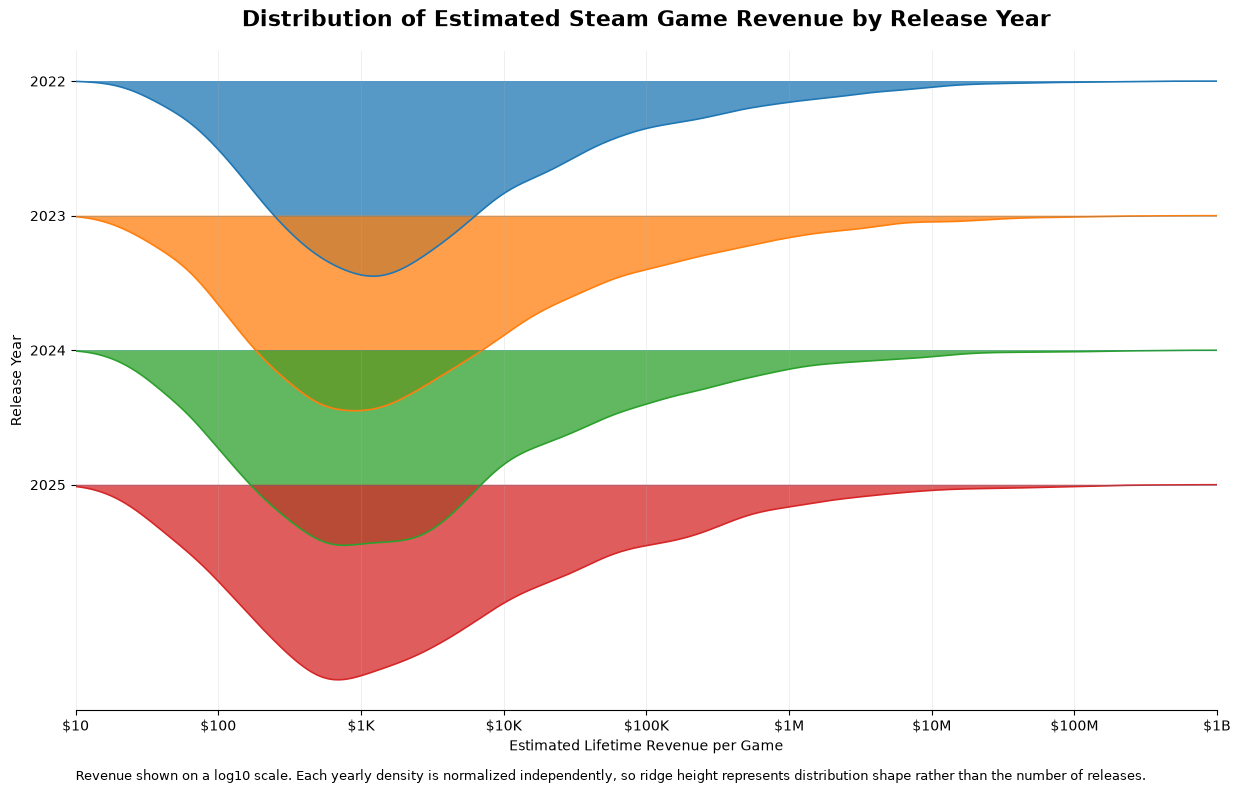

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

START_YEAR = 2010
END_YEAR = 2025

ridge_df = games_revenue.loc[
    games_revenue["release_year"].between(START_YEAR, END_YEAR)
    & games_revenue["estimated_revenue"].gt(0),
    ["release_year", "estimated_revenue"]
].copy()

ridge_df["release_year"] = ridge_df["release_year"].astype(int)
ridge_df["log10_revenue"] = np.log10(
    ridge_df["estimated_revenue"]
)

print(f"Games included: {len(ridge_df):,}")
print(
    f"Years included: "
    f"{ridge_df['release_year'].min()}–"
    f"{ridge_df['release_year'].max()}"
)

# ------------------------------------------------------------
# 2. Configure the density grid
# ------------------------------------------------------------

years = sorted(ridge_df["release_year"].unique())

# Display approximately $10 to $1 billion.
# Adjust these limits if needed.
X_MIN = 1
X_MAX = 9

x_grid = np.linspace(X_MIN, X_MAX, 700)

# Vertical distance between years and ridge height.
ROW_SPACING = 1.0
RIDGE_HEIGHT = 1.45

# ------------------------------------------------------------
# 3. Draw ridgelines
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, max(8, len(years) * 0.58))
)

for position, year in enumerate(years):
    values = ridge_df.loc[
        ridge_df["release_year"] == year,
        "log10_revenue"
    ].dropna()

    baseline = position * ROW_SPACING

    # KDE requires variation and more than one observation.
    if len(values) < 2 or values.nunique() < 2:
        continue

    kde = gaussian_kde(values, bw_method="scott")
    density = kde(x_grid)

    # Normalize each year's curve independently.
    # This compares distribution shape rather than release volume.
    density = density / density.max() * RIDGE_HEIGHT

    ax.fill_between(
        x_grid,
        baseline,
        baseline + density,
        alpha=0.75,
        linewidth=0
    )

    ax.plot(
        x_grid,
        baseline + density,
        linewidth=1.2
    )

    ax.axhline(
        baseline,
        linewidth=0.5,
        alpha=0.35
    )

# ------------------------------------------------------------
# 4. Format axes
# ------------------------------------------------------------

ax.set_yticks(
    np.arange(len(years)) * ROW_SPACING
)

ax.set_yticklabels(years)

# Most recent year at the top.
ax.invert_yaxis()

revenue_ticks = np.arange(1, 10)

revenue_labels = [
    "$10",
    "$100",
    "$1K",
    "$10K",
    "$100K",
    "$1M",
    "$10M",
    "$100M",
    "$1B",
]

ax.set_xticks(revenue_ticks)
ax.set_xticklabels(revenue_labels)
ax.set_xlim(X_MIN, X_MAX)

ax.set_xlabel("Estimated Lifetime Revenue per Game")
ax.set_ylabel("Release Year")

ax.set_title(
    "Distribution of Estimated Steam Game Revenue by Release Year",
    fontsize=16,
    weight="bold",
    pad=18
)

ax.text(
    0,
    -0.09,
    (
        "Revenue shown on a log10 scale. Each yearly density is "
        "normalized independently, so ridge height represents "
        "distribution shape rather than the number of releases."
    ),
    transform=ax.transAxes,
    fontsize=9,
    va="top"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.2,
    linewidth=0.7
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

START_YEAR = 2010
END_YEAR = 2025
TOP_N = 10

# ------------------------------------------------------------
# Prepare original game-level data
# ------------------------------------------------------------

top_games_source = games_revenue.loc[
    games_revenue["release_year"].between(START_YEAR, END_YEAR)
    & games_revenue["estimated_revenue"].notna()
    & games_revenue["estimated_revenue"].gt(0)
].copy()

top_games_source["release_year"] = (
    top_games_source["release_year"].astype(int)
)

# ------------------------------------------------------------
# Rank games within each release year
# ------------------------------------------------------------

top_games_source["revenue_rank"] = (
    top_games_source
    .groupby("release_year")["estimated_revenue"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top_10_games = (
    top_games_source.loc[
        top_games_source["revenue_rank"] <= TOP_N
    ]
    .sort_values(
        ["release_year", "revenue_rank"]
    )
    .copy()
)

# ------------------------------------------------------------
# Calculate total yearly revenue for comparison
# ------------------------------------------------------------

yearly_total_revenue = (
    top_games_source
    .groupby("release_year", as_index=False)
    .agg(
        total_year_revenue=(
            "estimated_revenue",
            "sum"
        ),
        games_with_revenue=(
            "appid",
            "count"
        )
    )
)

# ------------------------------------------------------------
# Summarize the top 10 for each year
# ------------------------------------------------------------

top_10_summary = (
    top_10_games
    .groupby("release_year", as_index=False)
    .agg(
        top_10_revenue=(
            "estimated_revenue",
            "sum"
        ),
        number_one_game_revenue=(
            "estimated_revenue",
            "max"
        ),
        average_top_10_revenue=(
            "estimated_revenue",
            "mean"
        ),
        median_top_10_revenue=(
            "estimated_revenue",
            "median"
        ),
        games_in_top_group=(
            "appid",
            "count"
        )
    )
    .merge(
        yearly_total_revenue,
        on="release_year",
        how="left"
    )
)

top_10_summary["top_10_revenue_share"] = (
    top_10_summary["top_10_revenue"]
    / top_10_summary["total_year_revenue"]
)

top_10_summary = top_10_summary[
    [
        "release_year",
        "games_with_revenue",
        "top_10_revenue",
        "number_one_game_revenue",
        "average_top_10_revenue",
        "median_top_10_revenue",
        "total_year_revenue",
        "top_10_revenue_share",
    ]
].sort_values("release_year")

# ------------------------------------------------------------
# Display formatted yearly summary
# ------------------------------------------------------------

display(
    top_10_summary.style.format(
        {
            "games_with_revenue": "{:,.0f}",
            "top_10_revenue": "${:,.0f}",
            "number_one_game_revenue": "${:,.0f}",
            "average_top_10_revenue": "${:,.0f}",
            "median_top_10_revenue": "${:,.0f}",
            "total_year_revenue": "${:,.0f}",
            "top_10_revenue_share": "{:.1%}",
        }
    ).hide(axis="index")
)

# ------------------------------------------------------------
# Display the individual top 10 games for each year
# ------------------------------------------------------------

detail_columns = [
    "release_year",
    "revenue_rank",
    "name",
    "appid",
    "estimated_revenue",
    "total_reviews",
    "price",
]

available_detail_columns = [
    column
    for column in detail_columns
    if column in top_10_games.columns
]

display(
    top_10_games[available_detail_columns]
    .style.format(
        {
            "estimated_revenue": "${:,.0f}",
            "total_reviews": "{:,.0f}",
            "price": "${:,.2f}",
        },
        na_rep="—"
    )
    .hide(axis="index")
)

release_year,games_with_revenue,top_10_revenue,number_one_game_revenue,average_top_10_revenue,median_top_10_revenue,total_year_revenue,top_10_revenue_share
2010,226,"$364,573,361","$90,908,138","$36,457,336","$32,015,884","$456,083,328",79.9%
2011,232,"$786,708,468","$316,497,162","$78,670,847","$26,049,169","$935,871,910",84.1%
2012,285,"$426,248,285","$194,775,568","$42,624,828","$18,650,306","$616,476,686",69.1%
2013,398,"$643,190,332","$227,199,311","$64,319,033","$38,802,236","$1,007,315,813",63.9%
2014,"1,387","$587,654,846","$115,749,711","$58,765,485","$47,911,280","$1,302,458,380",45.1%
2015,"2,220","$1,375,212,645","$289,905,175","$137,521,264","$126,304,772","$2,361,433,448",58.2%
2016,"3,532","$2,885,655,996","$1,117,006,301","$288,565,600","$191,160,853","$4,242,370,079",68.0%
2017,"4,932","$1,096,773,444","$324,962,158","$109,677,344","$97,645,766","$2,421,833,898",45.3%
2018,"6,021","$2,842,290,478","$1,104,453,097","$284,229,048","$190,091,577","$4,678,517,444",60.8%
2019,"5,571","$1,624,710,739","$494,810,756","$162,471,074","$95,088,347","$3,132,014,581",51.9%


release_year,revenue_rank,name,appid,estimated_revenue,total_reviews,price
2010,1,Sid Meier's Civilization® V,8930,"$90,908,138","204,265",$9.89
2010,2,Sid Meier's Civilization® V,50100,"$62,501,487","140,437",$9.89
2010,3,Fallout: New Vegas,22380,"$51,130,035","227,700",$4.99
2010,4,Mount & Blade: Warband,48700,"$37,366,243","166,405",$4.99
2010,5,Call of Duty®: Black Ops,42700,"$36,184,399","40,225",$19.99
2010,6,S.T.A.L.K.E.R.: Call of Pripyat,41700,"$27,847,369","30,957",$19.99
2010,7,STAR WARS™ Empire at War - Gold Pack,32470,"$17,728,004","39,435",$9.99
2010,8,Call of Duty®: Black Ops,42710,"$15,412,890","17,134",$19.99
2010,9,Batman: Arkham Asylum Game of the Year Edition,35140,"$13,224,037","73,651",$3.99
2010,10,Assassin's Creed 2,33230,"$12,270,759","54,646",$4.99


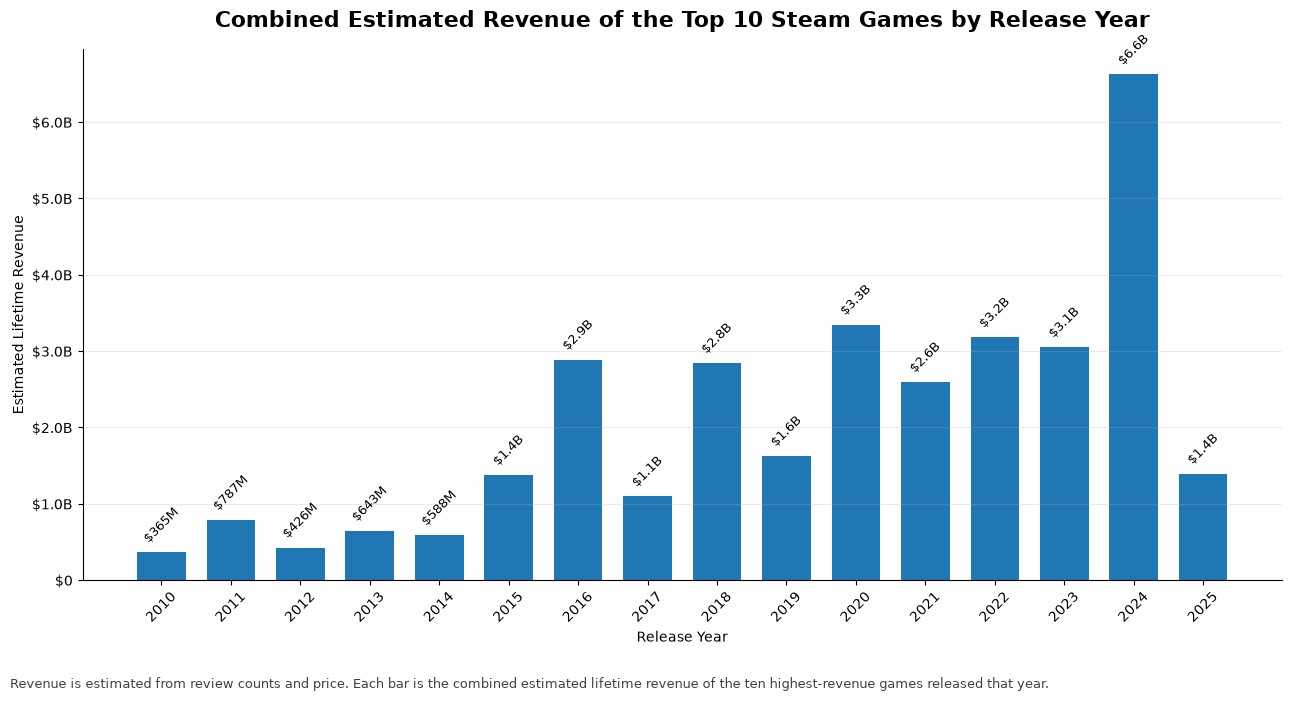

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Make sure the data is ordered by year
plot_data = top_10_summary.sort_values("release_year").copy()

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    plot_data["release_year"],
    plot_data["top_10_revenue"],
    width=0.7
)

# Format the y-axis as dollars
def format_dollars(value, position):
    if value >= 1_000_000_000:
        return f"${value / 1_000_000_000:.1f}B"
    if value >= 1_000_000:
        return f"${value / 1_000_000:.0f}M"
    if value >= 1_000:
        return f"${value / 1_000:.0f}K"
    return f"${value:,.0f}"

ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))

# Add a value above each bar
for bar, revenue in zip(bars, plot_data["top_10_revenue"]):
    ax.annotate(
        format_dollars(revenue, None),
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=45
    )

ax.set_title(
    "Combined Estimated Revenue of the Top 10 Steam Games by Release Year",
    fontsize=16,
    weight="bold",
    pad=16
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Estimated Lifetime Revenue")

ax.set_xticks(plot_data["release_year"])
ax.tick_params(axis="x", rotation=45)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Revenue is estimated from review counts and price. "
        "Each bar is the combined estimated lifetime revenue of the "
        "ten highest-revenue games released that year."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

MIN_REVENUE = 100_000
MAX_REVENUE = 1_000_000
START_YEAR = 2020
END_YEAR = 2025

games_100k_to_1m = (
    games_revenue.loc[
        games_revenue["release_year"].between(START_YEAR, END_YEAR)
        & games_revenue["estimated_revenue"].between(
            MIN_REVENUE,
            MAX_REVENUE,
            inclusive="both"
        )
    ]
    .copy()
    .sort_values(
        ["release_year", "estimated_revenue"],
        ascending=[True, False]
    )
)

columns_to_show = [
    "release_year",
    "name",
    "appid",
    "estimated_revenue",
    "price",
    "total_reviews",
    "positive",
    "negative",
]

columns_to_show = [
    column for column in columns_to_show
    if column in games_100k_to_1m.columns
]

print(
    f"Found {len(games_100k_to_1m):,} games released from "
    f"{START_YEAR}–{END_YEAR} with estimated revenue between "
    f"${MIN_REVENUE:,.0f} and ${MAX_REVENUE:,.0f}."
)

#display(
#    games_100k_to_1m[columns_to_show]
#    .style
#    .format(
#        {
#            "estimated_revenue": "${:,.0f}",
#            "price": "${:,.2f}",
#            "total_reviews": "{:,.0f}",
#            "positive": "{:,.0f}",
#            "negative": "{:,.0f}",
#        },
#        na_rep="—"
#    )
#    .hide(axis="index")
#)

Found 3,692 games released from 2020–2025 with estimated revenue between $100,000 and $1,000,000.


In [ ]:
games_per_year = (
    games_100k_to_1m
    .groupby("release_year")
    .size()
    .rename("number_of_games")
    .reset_index()
)

display(games_per_year)

,release_year,number_of_games
0,2020,523
1,2021,573
2,2022,594
3,2023,691
4,2024,833
5,2025,478


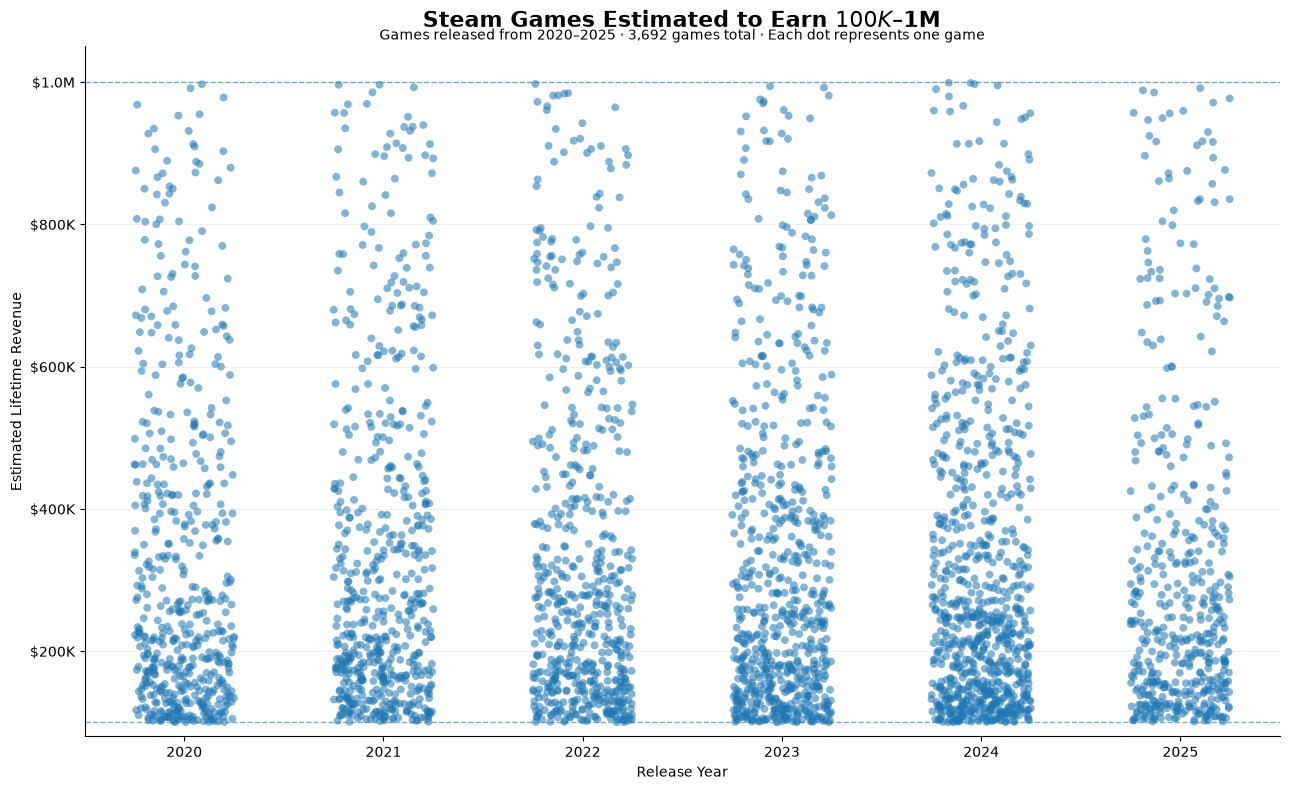

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# Filter games
# ------------------------------------------------------------

plot_games = games_revenue.loc[
    games_revenue["release_year"].between(2020, 2025)
    & games_revenue["estimated_revenue"].between(
        100_000,
        1_000_000,
        inclusive="both"
    )
].copy()

plot_games["release_year"] = plot_games["release_year"].astype(int)

# Add horizontal jitter so overlapping games remain visible
rng = np.random.default_rng(42)

plot_games["plot_x"] = (
    plot_games["release_year"]
    + rng.uniform(-0.25, 0.25, size=len(plot_games))
)

# ------------------------------------------------------------
# Plot every game
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 8))

ax.scatter(
    plot_games["plot_x"],
    plot_games["estimated_revenue"],
    alpha=0.55,
    s=32,
    edgecolors="none"
)

# Revenue-band boundaries
ax.axhline(
    100_000,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.axhline(
    1_000_000,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

def format_dollars(value, position):
    if value >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    return f"${value / 1_000:.0f}K"

ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))

ax.set_xticks(range(2020, 2026))
ax.set_xlim(2019.5, 2025.5)
ax.set_ylim(80_000, 1_050_000)

ax.set_xlabel("Release Year")
ax.set_ylabel("Estimated Lifetime Revenue")

ax.set_title(
    "Steam Games Estimated to Earn $100K–$1M",
    fontsize=16,
    weight="bold",
    pad=14
)

ax.text(
    0.5,
    1.01,
    (
        f"Games released from 2020–2025 · "
        f"{len(plot_games):,} games total · Each dot represents one game"
    ),
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()